<a href="https://colab.research.google.com/github/moise-github/HoughVG/blob/main/TestHoughVGGoogleColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Clonage du dépôt GitHub officiel :

In [ ]:
!git clone https://github.com/moise-github/HoughVG.git
%cd HoughVG


Cloning into 'HoughVG'...
remote: Enumerating objects: 656, done.
remote: Counting objects: 100% (656/656), done.
remote: Compressing objects: 100% (643/643), done.
remote: Total 656 (delta 555), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (656/656), 1.06 MiB | 14.87 MiB/s, done.
Resolving deltas: 100% (555/555), done.
/content/HoughVG


2. Installation des dépendances nécessaires :

In [ ]:
!pip install numpy opencv-python matplotlib pymp-pypi


  Preparing metadata (setup.py) ... done
  Created wheel for pymp-pypi: filename=pymp_pypi-0.5.0-py3-none-any.whl size=10314 sha256=dcb240c8541e3c1b266e6879f7c597c5dc27daa9e7b73b0c66d5401b26a54cd2
  Stored in directory: /root/.cache/pip/wheels/3d/6c/ef/356575a818508a9c37c4513a5139063d522ea002bcebd15bbe
Successfully built pymp-pypi


In [ ]:
import unittest
from HoughVG import HoughLine
import cv2
import time
from google.colab.patches import cv2_imshow

In [ ]:
imge_auto = cv2.imread('/content/HoughVG/HoughVG/test/images/autoroute2.jpg')

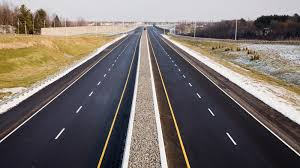

In [ ]:
if imge_auto is None :
    print('Could not open or find the image')
else:
    cv2_imshow(imge_auto)

In [ ]:
def ImgPreprocessing(imge,EdgesThresholdMin, EdgesThresholdMax):
    img = cv2.Canny(imge, EdgesThresholdMin, EdgesThresholdMax, None, 3)
    return img

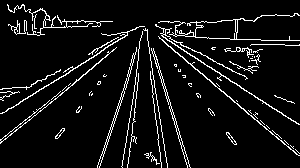

THR_road:Lines detection time : 0.2509336471557617 sec


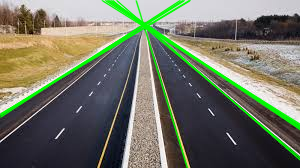

False

In [ ]:
colors=(0, 255, 0)
Rate=0.4
l=3
L=3
Threshold=50
EdgesThresholdMax=500
EdgesThresholdMin=200
img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
cv2_imshow(img)
t1=time.time()
accum, accum_max,lines = HoughLine.Rectangular(img,l,L,Rate,Threshold)
t2=time.time()
T=t2-t1
print('THR_road:Lines detection time :', T, 'sec' )
if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')

img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
cv2_imshow(img2)
cv2.imwrite('./images/test_THR_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
cv2.imwrite('./images/test_THR_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
cv2.imwrite('./images/test_THR_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)


Skipping building tests because the image was not loaded.


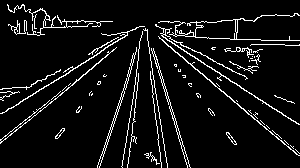

.

THR_road:Lines detection time : 0.29972219467163086 sec


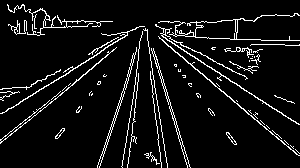

.

THS_road:Lines detection time : 0.5711936950683594 sec


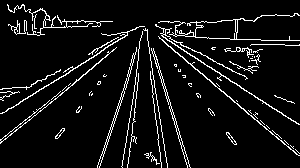

.

THT1_road:Lines detection time : 0.39241814613342285 sec


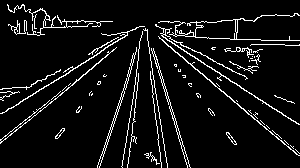

.

THT2_road:Lines detection time : 0.4626631736755371 sec


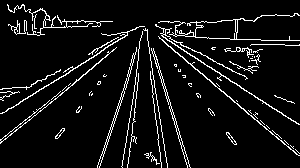

.

THH_road:Lines detection time : 0.315354585647583 sec


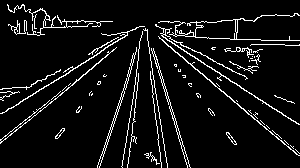

.
----------------------------------------------------------------------
Ran 6 tests in 2.249s

OK


THO_road:Lines detection time : 0.15214061737060547 sec


<unittest.runner.TextTestResult run=6 errors=0 failures=0>

In [ ]:
import unittest
from HoughVG import HoughLine
import cv2
import time
from google.colab.patches import cv2_imshow
imge_auto = cv2.imread('/content/HoughVG/HoughVG/test/images/autoroute2.jpg')
imge_Build = cv2.imread('/content/HoughVG/HoughVG/test/images/univ.png')
def ImgPreprocessing(imge,EdgesThresholdMin, EdgesThresholdMax):
    img = cv2.Canny(imge, EdgesThresholdMin, EdgesThresholdMax, None, 3)
    return img

class TestHoughLine_Road(unittest.TestCase):
    def test_Standard(self):
        colors=(0, 255, 0)
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max,lines= HoughLine.Standard(img,Threshold)
        t2=time.time()
        T=t2-t1
        print('THS_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')

        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
        cv2.imwrite('./images/test_THS_road_accum_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THS_road_accum_max_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THS_road_lines_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)

    def test_Rectangular(self):
        colors=(0, 255, 0)
        Rate=0.4
        l=3
        L=3
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max,lines= HoughLine.Rectangular(img,l,L,Rate,Threshold)
        t2=time.time()
        T=t2-t1
        print('THR_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')

        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)

        cv2.imwrite('./images/test_THR_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THR_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THR_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)

    def test_Triangular1(self):
        colors=(0, 255, 0)
        Rate=0.4
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max,lines= HoughLine.Triangular1(img,Rate,Threshold)
        t2=time.time()
        T=t2-t1
        print('THT1_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
        cv2.imwrite('./images/test_THT1_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THT1_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THT1_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)

    def test_Triangular2(self):
        colors=(0, 255, 0)
        Rate=0.4
        h=3
        b=3
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max,lines= HoughLine.Triangular2(img,h,b,Rate,Threshold)
        t2=time.time()
        T=t2-t1
        print('THT2_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
        cv2.imwrite('./images/test_THT2_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THT2_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THT2_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)


    def test_hexagonal(self):
        colors=(0, 255, 0)
        Rate=0.4
        gamma=2
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max,lines= HoughLine.Hexagonal(img,gamma,Rate,Threshold)
        t2=time.time()
        T=t2-t1
        print('THH_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
        cv2.imwrite('./images/test_THH_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THH_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THH_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)

    def test_octogonal(self):
        colors=(0, 255, 0)
        Rate=0.4
        gamma=2
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        img=ImgPreprocessing(imge_auto,EdgesThresholdMin, EdgesThresholdMax)
        cv2_imshow(img)
        t1=time.time()
        accum, accum_max, lines= HoughLine.Octogonal(img,gamma,Rate,Threshold)
        t2=time.time()
        T=t2-t1
        print('THO_road:Lines detection time :', T, 'sec' )
        if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
        img2=HoughLine.PlotHoughLine(imge_auto,lines,colors)
        cv2.imwrite('./images/test_THO_road_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
        cv2.imwrite('./images/test_THO_road_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
        cv2.imwrite('./images/test_THO_road_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)


class TestHoughLine_Building(unittest.TestCase):
    def test_Standard(self):
        colors=(0, 255, 0)
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)

            t1=time.time()
            accum, accum_max,lines= HoughLine.Standard(img,Threshold)
            t2=time.time()
            T=t2-t1
            print('THS_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')

            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THS_building_accum_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THS_building_accum_max_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THS_building_lines_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")

    def test_Rectangular(self):
        colors=(0, 255, 0)
        Rate=0.4
        l=3
        L=3
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)
            t1=time.time()
            accum, accum_max,lines= HoughLine.Rectangular(img,l,L,Rate,Threshold)
            t2=time.time()
            T=t2-t1
            print('THR_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THR_Building_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THR_Building_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THR_Building_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_l%02d'%l +'_L%02d'%L +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")

    def test_Triangular1(self):
        colors=(0, 255, 0)
        Rate=0.4
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)
            t1=time.time()
            accum, accum_max,lines= HoughLine.Triangular1(img,Rate,Threshold)
            t2=time.time()
            T=t2-t1
            print('THT1_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THT1_Building_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THT1_Building_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THT1_Building_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")


    def test_Triangular2(self):
        colors=(0, 255, 0)
        Rate=0.4
        h=3
        b=3
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)
            t1=time.time()
            accum, accum_max,lines= HoughLine.Triangular2(img,h,b,Rate,Threshold)
            t2=time.time()
            T=t2-t1
            print('THT2_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THT2_Building_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THT2_Building_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THT2_Building_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_h%02d'%h +'_b%02d'%b +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")


    def test_hexagonal(self):
        colors=(0, 255, 0)
        Rate=0.4
        gamma=2
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)
            t1=time.time()
            accum, accum_max,lines= HoughLine.Hexagonal(img,gamma,Rate,Threshold)
            t2=time.time()
            T=t2-t1
            print('THH_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THH_Building_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THH_Building_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THH_Building_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")

    def test_octogonal(self):
        colors=(0, 255, 0)
        Rate=0.4
        gamma=2
        Threshold=50
        EdgesThresholdMax=500
        EdgesThresholdMin=200
        if imge_Build is not None:
            img=ImgPreprocessing(imge_Build,EdgesThresholdMin, EdgesThresholdMax)
            cv2_imshow(img)
            t1=time.time()
            accum, accum_max, lines= HoughLine.Octogonal(img,gamma,Rate,Threshold)
            t2=time.time()
            T=t2-t1
            print('THO_building:Lines detection time :', T, 'sec' )
            if T>=60 : print('soit :', int(T/60), 'min :',T%60, 'sec')
            img2=HoughLine.PlotHoughLine(imge_Build,lines,colors)
            cv2.imwrite('./images/test_THO_Building_accum_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum)
            cv2.imwrite('./images/test_THO_Building_accum_max_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', accum_max)
            cv2.imwrite('./images/test_THO_Building_lines_Rate'+'%02d'%Rate +'_Threshold %02d'%Threshold +'_Gamma%02d'%gamma +'_CannyMin%02d'%EdgesThresholdMin +'_CannyMax%02d'%EdgesThresholdMax +'.png', img2)
        else:
            print("Image for building test not loaded.")


# Run the tests
loader = unittest.TestLoader()
suite = loader.loadTestsFromTestCase(TestHoughLine_Road)
# Add building tests only if the image is loaded
if imge_Build is not None:
    suite.addTests(loader.loadTestsFromTestCase(TestHoughLine_Building))
else:
    print("Skipping building tests because the image was not loaded.")

runner = unittest.TextTestRunner()
runner.run(suite)

In [ ]:
!ls /content/HoughVG/HoughVG/test/images/

autoroute2.jpg	building_glass.jpg  fingerprint_2  ligne.PNG  p2.png
Big_DB		fingerprint_1	    lena.PNG	   Little_DB  univ.PNG
